# Importing Dependencies

In [29]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

# Defining Variables

$n$: Number of steps

$T$: Time horizon

$\Delta t$: Time step size

$\rho$: Correlation coefficient for $\varepsilon$'s

$\kappa$: Volatility mean reversion rate (higher $\implies$ Faster)

$\theta$: Mean volatility level

$\xi$: Volatility of volatility

$\mu$: Expected return

$S_0$: Initial asset price

$\varepsilon^{S}$: Standard normal random variable simulating $dW^S_t$

$\varepsilon^{v}$: Standard normal random variable simulating $dW^v_t$

In [30]:
num_paths = 100
n = 252
rho = -0.7
T = 1
dt = T / n
theta = 0.05
kappa = 6
xi = 0.4
mu = 0.03
S0 = 100
epsilon_S = np.random.normal(0,1,(n,num_paths))
epsilon_v = rho * epsilon_S + np.sqrt(1 - rho ** 2) * np.random.normal(0,1,(n,num_paths))
v = np.zeros((n + 1, num_paths))
v[0,:] = theta
S = np.zeros((n + 1, num_paths))
S[0, :] = S0

# Simulating Paths

**Stochastic volatility component:**

$$v_{j,i+1} = v_{j,i} + \kappa(\theta - \max(v_{j,i},0))\Delta t + \xi \sqrt{\max(v_{j,i},0)}\sqrt{\Delta t}\varepsilon^{v}_{j,i}$$

**Heston Model (Euler-Maruyama):**

$$S_{j,i+1} = S_{j,i} + \mu S_{j,i} \Delta t + \sqrt{\max(v_{j,i}, 0)} S_{j,i} \sqrt{\Delta t} \varepsilon^{S}_{j,i}$$

In [31]:
for i in range(0,n):
  v[i+1] = v[i] + kappa * (theta - np.maximum(v[i],0)) * dt + xi * np.sqrt(np.maximum(v[i], 0)) * np.sqrt(dt) * epsilon_v[i]
  S[i+1] = S[i] + mu * S[i] * dt + np.sqrt(np.maximum(v[i],0)) * S[i] * np.sqrt(dt) * epsilon_S[i]

# Plotting Paths

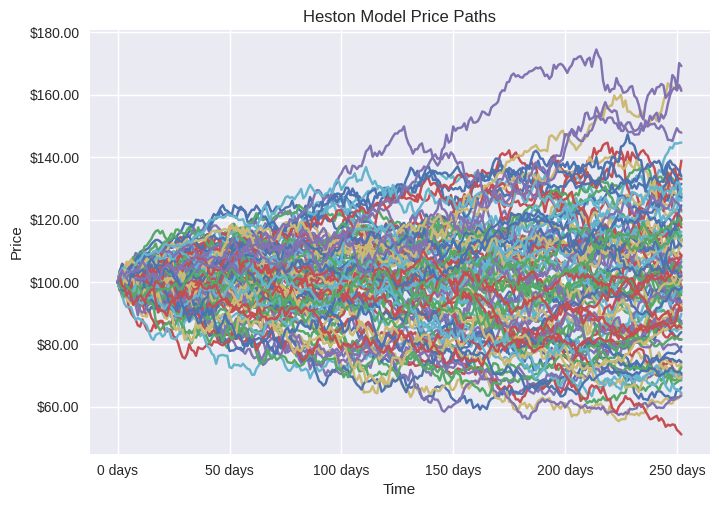

In [32]:
plt.plot(S)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Heston Model Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()